# Gradient Descent

In this exercise, we will create the necessary functions to perform the steps of a single Gradient Descent Epoch. We will then combine the functions and create a loop through the entire Gradient Descent procedure.

## 1. Data Exploration

We will import the following dataset of materials with their mineral contents for you

In [1]:
import pandas as pd

data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/gradient_descent_ingredients_zinc_phosphorous.csv")
data.head()

,aliment,zinc,phosphorus
0,Durum wheat pre-cooked. whole grain. cooked. u...,0.120907,0.193784
1,Asian noodles. plain. cooked. unsalted,0.047859,0.060329
2,Rice. brown. cooked. unsalted,0.156171,0.201097
3,Rice. cooked. unsalted,0.065491,0.045704
4,Rice. parboiled. cooked. unsalted,0.025189,0.045704


👇 We can visualize a somewhat Linear relationship between `Phosphorus` and `Zinc`.   

Let's use Gradient Descent to find the best fit line between them!

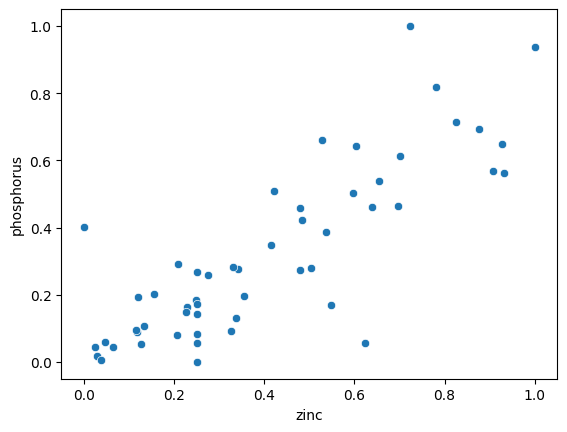

In [2]:
import seaborn as sns

sns.scatterplot(data=data, x='zinc', y='phosphorus');

❓ Create two `np.Array`s
- `data_X` for zinc
- `data_Y` for phosphorus

In [3]:
import numpy as np

data_X = np.array(data['zinc'])
data_Y = np.array(data['phosphorus'])

In [4]:
assert (data_X.shape == (53,))
assert (data_Y.shape == (53,))

## 2. Coding One Epoch

In this section of the exercise, you will define the core functions used to update the parameters during one epoch $\color {red}{(k)}$ of gradient descent. Recall the following formula:

$$
\beta_0^{\color {red}{(k+1)}} = \beta_0^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_0}(\beta^{\color{red}{(k)}})
$$


$$
\beta_1^{\color {red}{(k+1)}} = \beta_1^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_1}(\beta^{\color {red}{(k)}})
$$

### 2.1 Hypothesis Function

$$
\hat{y} =  a x + b
$$

❓ Define the Linear Regression hypothesis function. Let `a` be the slope and `b` be the y-intercept.

In [5]:
def h(X,a,b):
    y_pred = a * X + b
    return y_pred

### 2.2 Loss Function

$$
Sum\ of\ Squared\ Residuals\ Loss = \sum_{i=0}^n (y^{(i)} - \hat{y}^{(i)} )^2
$$

❓ Define the SSR Loss Function for the Hypothesis Function using the equation above. Reuse the `h` function coded above when writing your new function.

In [6]:
import numpy as np

def loss(X,Y,a,b):
    Y_pred = h(X,a,b)
    return np.sum((Y - Y_pred) ** 2)
    return loss

❓ What would the total Loss computed across all materials in our dataset be if:
- a = 1 
- b = 1

In [7]:
loss(data_X,data_Y,1,1)

63.868506986115456

### 2.3 Gradient

$$
\frac{d\ SSR}{d\ slope}= \sum_{i=0}^n -2  x_i (y^{(i)} - \hat{y}^{(i)} )
$$

$$
\frac{d\ SSR}{d\ intercept}= \sum_{i=0}^n -2(y^{(i)} - \hat{y}^{(i)} ) 
$$

❓ Define a function that computes the partial derivatives of the Loss Function with respect to the parameters `a` and `b` at a given point.

<details>
<summary>💡 Hint</summary>
Again, you should reuse the Hypothesis Function in your new function to compute the predictions at the given points.
</details>

In [9]:
def gradient(X,Y,a,b):
    Y_pred = h(X,a,b)
    d_a = np.sum(-2*(Y-Y_pred)*X)
    d_b = np.sum(-2*(Y-Y_pred))
    return d_a, d_b

❓ Using your function, what would the partial derivatives of each parameter be if:
- a = 1
- b = 1

In [10]:
gradient(data_X,data_Y,1,1)

(48.459065809109006, 115.17923733301406)

### 2.4 Step Sizes

$$
step\ size = gradient \cdot learning\ rate
$$

❓ Define a function that computes the step sizes along each parameter (`a`, `b`) based on the derivatives (`d_a`, `d_b`) and a `learning_rate` equal to `0.01` by default

In [11]:
def steps(d_a,d_b, learning_rate = 0.01):
    step_a = d_a * learning_rate
    step_b = d_b * learning_rate
    return (step_a, step_b)

❓ What would the steps (`step_a`, `step_b`) be for the derivatives computed above for (`a`, `b`) = (1, 1)?

In [12]:
d_a,d_b = gradient(data_X,data_Y,1,1)
steps(d_a,d_b, learning_rate = 0.01)

(0.4845906580910901, 1.1517923733301405)

### 2.5 Updating Parameters (a, b)

$$
updated\ parameter = old\ parameter\ value - step\ size
$$

❓ Define a function that computes updated parameter values from old parameter values and step sizes.

In [13]:
def update_params(a, b, step_a, step_b):
    a_new = a - step_a
    b_new = b - step_b
    return a_new , b_new

### 2.6 A Full Epoch

❓ Using the functions you just created, compute the updated parameters at the end of the first Epoch if you started with:
- a = 1
- b = 1

In [14]:
a = 1
b = 1

d_a,d_b = gradient(data_X,data_Y,a,b)
step_a,step_b = steps(d_a,d_b, learning_rate = 0.01)
a_new,b_new = update_params(a,b,step_a,step_b)

print(a_new)
print(b_new)

0.5154093419089099
-0.1517923733301405


## 3. Gradient Descent

❓ Now that you have the necessary functions for Gradient Descent, loop through epochs until convergence.

- Initialize the parameters `a = 1` and `b = 1`
- Consider convergence as **100 epochs**
- Don't forget to start each new epoch with the updated parameters
- At each epoch, append the `loss`, `a`, and `b` values to their respective lists `loss_history`, `a_history`, and `b_history`

In [15]:
a = 1
b = 1

loss_history = []
a_history = []
b_history = []

for epoch in range(100):

    a_history.append(a)
    b_history.append(b)

    loss_epoch = loss(data_X,data_Y,a,b)
    loss_history.append(loss_epoch)
    
    d_a,d_b = gradient(data_X,data_Y,a,b)

    step_a,step_b = steps(d_a,d_b)

    a, b = update_params(a, b, step_a, step_b)

pd.DataFrame({'a': a_history, 'b': b_history, 'loss': loss_history}).tail()

,a,b,loss
95,0.768603,0.007119,1.082069
96,0.768619,0.007112,1.082069
97,0.768633,0.007106,1.082069
98,0.768647,0.007100,1.082069
99,0.768660,0.007094,1.082069


❓ What are the parameter values at the end of 100 epochs? Save them in `a_100` and `b_100` variables respectively

In [16]:
a_100 = a
b_100 = b
print(a,b)

0.768671510620374 0.00708932115622393


In [17]:
# 🧪 Test your code
from nbresult import ChallengeResult
result = ChallengeResult('descent',
                         a_100=a_100,
                         b_100=b_100)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/gradient-descent/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 2 items

test_descent.py::TestDescent::test_a PASSED                              [ 50%]
test_descent.py::TestDescent::test_b PASSED                              [100%]

============================== 2 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/descent.pickle

git commit -m 'Completed descent step'

git push origin master



## 4. Visual Check

❓ Wrap this iterative approach into a `gradient_descent()` method that returns `new_a`, `new_b`, and `history`, a dictionary containing the following lists:
- `loss_history`
- `a_history`
- `b_history`

In [ ]:
def gradient_descent(X, Y, a_init=1, b_init=1, learning_rate=0.001, n_epochs=100):
    pass  # YOUR CODE HERE
    return a, b, history

❓ Using the parameters from your Gradient Descent, plot the best fit line between Zinc and Phosphorus.

In [ ]:
# YOUR CODE HERE

## 5. Visualize Your Descent

🎯 Our goal is to plot our loss function and the gradient descent steps on a 2D surface using matplotlib's `contourf`

❓ Start by generating the data needed for the plot:
- `range_a`: a range of 100 evenly spaced values between -1 and 1 for `a`
- `range_b`: a range of 100 evenly spaced values between -1 and 1 for `b`
- `Z`: a 2D-array where each element `Z[j,i]` equals the value of the loss function at the point `a` = `range_a[i]` and `b` = `range_b[j]`

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

❓ Now, in a single subplot, plot:
- your loss function as a 2D-surface using matplotlib [contourf](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.contourf.html) with 3 parameters
- a scatter plot of all the historical (a, b) points as red dots to visualize your gradient descent!

Change your learning rate and observe its effect on the plot!

In [ ]:
# YOUR CODE HERE

❓ [optional] What about 3D? Try plotting the same data on a [plot.ly 3D contour chart](https://plotly.com/python/3d-surface-plots/) below

In [ ]:
import plotly.graph_objects as go

surface = go.Surface(x=range_a, y=range_b, z=Z)
scatter = go.Scatter3d(x=history['a'], y=history['b'], z=history['loss'], mode='markers')
fig = go.Figure(data=[surface, scatter])

#fig.update_layout(title='Loss Function', autosize=False, width=500, height=500)
fig.show()

❓ Plot the history of `loss` values as a function of the number of `epochs`. Try with multiple variations of `learning_rate` from 0.001 to 0.01 and make sure you understand the difference

In [ ]:
# YOUR CODE HERE

## 6. With Sklearn...

❓ Using Sklearn, train a Linear Regression model on the same data. Compare its parameters with the ones computed by your Gradient Descent.

In [ ]:
# YOUR CODE HERE

They should be almost identical!